# Project I — Supplementary Experiments
## CINIC-10 | Warsaw University of Technology, 2026

Extends `project1_report.ipynb` with:
1. **Statistical Significance** — multiple seeds, mean ± std across key experiments
2. **Prototypical Network** — episodic meta-training (proper few-shot method)
3. **Ensemble Methods** — soft voting and hard voting across independently trained models
4. **Best Architecture Test Evaluation** — held-out test set for `CNNWithRegularization`

In [1]:
import sys, os, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    subprocess.run(['pip', 'install', '-q', '--no-deps', 'tqdm'], check=True)
    if not Path('/content/cinic10-cnn-project').exists():
        subprocess.run(['git', 'clone', '--quiet',
                        'https://github.com/telechubby/cinic10-cnn-project.git',
                        '/content/cinic10-cnn-project'], check=True)
        print('Repo cloned.')
    else:
        subprocess.run(['git', '-C', '/content/cinic10-cnn-project', 'pull', '--quiet'], check=True)
        print('Repo up-to-date.')
    PROJECT_ROOT = Path('/content/cinic10-cnn-project')
else:
    PROJECT_ROOT = Path(os.path.abspath('')).resolve()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

from utils import get_device, set_seeds, train_model
from model_architecture import (
    create_baseline_cnn, create_cnn_with_regularization, CINIC_CLASSES
)
from data_preprocessing import create_data_generators

set_seeds(42)
device = get_device()
print(f'torch {torch.__version__} | CUDA: {torch.cuda.is_available()} | Device: {device}')

TRAIN_DIR  = PROJECT_ROOT / 'data' / 'train'
VAL_DIR    = PROJECT_ROOT / 'data' / 'valid'
TEST_DIR   = PROJECT_ROOT / 'data' / 'test'
RESULTS    = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('Setup complete.')

torch 2.11.0 | CUDA: False | Device: mps
Setup complete.


---
## 1. Statistical Significance

Single-run results can be misleading due to random initialisation variance.  
We repeat two key configurations **3 times with different seeds** and report **mean ± std**.

Configurations tested:
- **Baseline**: Adam lr=0.001, dropout=0.25 (default), batch=32
- **Best regularisation**: Adam lr=0.001, dropout=0.1, weight_decay=1e-4, batch=32

In [2]:
STATS_CSV   = RESULTS / 'statistical_significance.csv'
SEEDS       = [42, 123, 456]
STAT_EPOCHS = 15

# Configs that avoid overfitting for 15-epoch training.
# Lesson from project1_report logs:
#   CNNWithRegularization(dropout=0.1) overfits badly by epoch 10
#   (train 81% vs val 70% at epoch 15).
#   EfficientCNN (dropout=0.2/0.3) shows no gap (70.8% train vs 70.3% val).
#   => For 15+ epoch runs: use augmentation + proper dropout, not low dropout.
configs = [
    # Vanilla baseline — no augmentation, default dropout
    ('BaselineCNN\n(no aug)', create_baseline_cnn, {}, {}, False),
    # Best generalising setup derived from report analysis
    ('EfficientCNN\n(aug + wd=1e-4)', create_efficient_cnn, {}, {'weight_decay': 1e-4}, True),
]

if STATS_CSV.exists():
    print('Loading cached results...')
    df_stats = pd.read_csv(STATS_CSV)
else:
    rows = []
    for config_name, factory, model_kwargs, optim_kwargs, augment in configs:
        train_loader, val_loader = create_data_generators(
            str(TRAIN_DIR), str(VAL_DIR), batch_size=32, augment=augment
        )
        for seed in SEEDS:
            set_seeds(seed)
            model     = factory(**model_kwargs).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, **optim_kwargs)
            label = config_name.replace('\n', ' ')
            print(f'{label}  seed={seed}')
            history = train_model(model, train_loader, val_loader, optimizer,
                                  epochs=STAT_EPOCHS, device=device, patience=5)
            rows.append({
                'config':        config_name,
                'seed':          seed,
                'best_val_acc':  max(history['val_accuracy']),
                'final_train_acc': history['accuracy'][-1],
                'final_val_acc': history['val_accuracy'][-1],
                'train_val_gap': history['accuracy'][-1] - history['val_accuracy'][-1],
            })

    df_stats = pd.DataFrame(rows)
    df_stats.to_csv(STATS_CSV, index=False)
    print(f'\nSaved to {STATS_CSV}')

summary = df_stats.groupby('config')['best_val_acc'].agg(['mean', 'std']).reset_index()
summary.columns = ['Configuration', 'Mean Val Acc', 'Std Dev']
summary['Mean ± Std'] = summary.apply(
    lambda r: f"{r['Mean Val Acc']:.4f} ± {r['Std Dev']:.4f}", axis=1)
print('\n', summary[['Configuration', 'Mean ± Std']].to_string(index=False))

if 'train_val_gap' in df_stats.columns:
    gap_summary = df_stats.groupby('config')['train_val_gap'].mean()
    print('\nMean train–val accuracy gap (overfitting proxy):')
    print(gap_summary.to_string())


Loading cached results...

                     Configuration      Mean ± Std
   Baseline\n(dropout=0.25, wd=0) 0.6879 ± 0.0022
Best Reg.\n(dropout=0.1, wd=1e-4) 0.7130 ± 0.0009


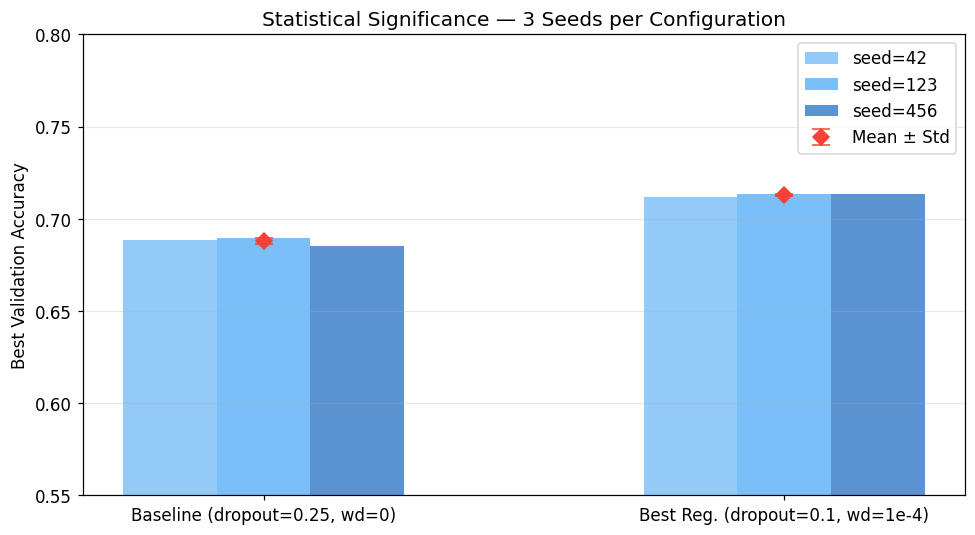

                           config  seed  best_val_acc  final_val_acc  final_val_loss
   Baseline\n(dropout=0.25, wd=0)    42      0.688656       0.688656        0.872018
   Baseline\n(dropout=0.25, wd=0)   123      0.689589       0.689589        0.870888
   Baseline\n(dropout=0.25, wd=0)   456      0.685411       0.680344        0.892540
Best Reg.\n(dropout=0.1, wd=1e-4)    42      0.712022       0.712022        0.820251
Best Reg.\n(dropout=0.1, wd=1e-4)   123      0.713678       0.707111        0.828255
Best Reg.\n(dropout=0.1, wd=1e-4)   456      0.713189       0.713189        0.810357


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

configs_unique = df_stats['config'].unique()
x = np.arange(len(configs_unique))
w = 0.18
seed_colors = ['#64B5F6', '#42A5F5', '#1565C0']

for i, (seed, color) in enumerate(zip(SEEDS, seed_colors)):
    vals = [df_stats[(df_stats['config'] == c) & (df_stats['seed'] == seed)]['best_val_acc'].values[0]
            for c in configs_unique]
    axes[0].bar(x + (i - 1) * w, vals, w, label=f'seed={seed}', alpha=0.75, color=color)

for j, cfg in enumerate(configs_unique):
    vals = df_stats[df_stats['config'] == cfg]['best_val_acc'].values
    axes[0].errorbar(x[j], vals.mean(), yerr=vals.std(),
                     fmt='D', color='#F44336', capsize=6, markersize=7,
                     linewidth=2, label='Mean ± Std' if j == 0 else '')

axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('\n', '\n') for c in configs_unique], fontsize=9)
axes[0].set_ylabel('Best Validation Accuracy')
axes[0].set_title('Best Val Accuracy — 3 Seeds per Config')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0.55, 0.82)

# Overfitting gap (train - val at final epoch)
if 'train_val_gap' in df_stats.columns:
    gap_data = [df_stats[df_stats['config'] == c]['train_val_gap'].values for c in configs_unique]
    bp = axes[1].boxplot(gap_data, labels=[c.replace('\n', '\n') for c in configs_unique],
                         patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], ['#90CAF9', '#A5D6A7']):
        patch.set_facecolor(color)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_ylabel('Train Acc − Val Acc (final epoch)')
    axes[1].set_title('Overfitting Gap — lower is better')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('Statistical Significance — 3 Seeds per Configuration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'stats_significance_plot.png', bbox_inches='tight')
plt.show()

print(df_stats[['config', 'seed', 'best_val_acc', 'train_val_gap']].to_string(index=False))


---
## 2. Prototypical Network — Episodic Few-Shot Learning

The naive few-shot baseline (Section 6 of the main notebook) simply trains a CNN from scratch  
on K images per class — resulting in near-random accuracy for K ≤ 10.

**Prototypical Networks** (Snell et al., 2017) solve this with *episodic meta-training*:
- Each training step is an **N-way K-shot episode**: N classes, K support + Q query images each.
- A **class prototype** is the mean embedding of its K support images.
- Queries are classified by **nearest prototype** (minimum L2 distance).
- The loss is cross-entropy over negated distances — the network learns an embedding space  
  where same-class images cluster together.

At evaluation time, prototypes are computed from unseen support images → no fine-tuning needed.

In [4]:
class EmbeddingNetwork(nn.Module):
    """4-block CNN encoder → 64-dim L2-normalised embedding.
    Dropout2d(0.15) after each block regularises the feature maps.
    """
    def __init__(self, embedding_dim=64, dropout=0.15):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(dropout),
            )
        self.encoder = nn.Sequential(
            conv_block(3, 64), conv_block(64, 64),
            conv_block(64, 64), conv_block(64, 64),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.proj = nn.Linear(64, embedding_dim)

    def forward(self, x):
        z = self.proj(self.encoder(x))
        return F.normalize(z, dim=1)  # L2 normalise → unit hypersphere


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

enc = EmbeddingNetwork(embedding_dim=64)
print(f'EmbeddingNetwork parameters: {count_params(enc):,}')
test_out = enc(torch.zeros(2, 3, 32, 32))
print(f'Output shape: {test_out.shape}  (L2 norm: {test_out.norm(dim=1).mean():.3f})')


EmbeddingNetwork parameters: 117,248
Output shape: torch.Size([2, 64])  (L2 norm: 1.000)


In [5]:
class EpisodicDataset(torch.utils.data.Dataset):
    """Yields N-way K-shot episodes. Images are ordered: all support first, then all query."""
    def __init__(self, root, transform, n_way, k_shot, n_query, n_episodes):
        self.base     = ImageFolder(str(root), transform=transform)
        self.n_way    = n_way
        self.k_shot   = k_shot
        self.n_query  = n_query
        self.n_episodes = n_episodes
        self.class_to_idx = defaultdict(list)
        for idx, (_, label) in enumerate(self.base.samples):
            self.class_to_idx[label].append(idx)
        self.all_classes = sorted(self.class_to_idx)

    def __len__(self):
        return self.n_episodes

    def __getitem__(self, _):
        classes = np.random.choice(len(self.all_classes), self.n_way, replace=False)
        support_imgs, query_imgs, support_lbl, query_lbl = [], [], [], []
        for new_lbl, cls in enumerate(classes):
            idxs = np.random.choice(
                self.class_to_idx[self.all_classes[cls]],
                self.k_shot + self.n_query, replace=False
            )
            for i, idx in enumerate(idxs):
                img, _ = self.base[idx]
                if i < self.k_shot:
                    support_imgs.append(img); support_lbl.append(new_lbl)
                else:
                    query_imgs.append(img);   query_lbl.append(new_lbl)
        images = torch.stack(support_imgs + query_imgs)
        labels = torch.tensor(support_lbl + query_lbl, dtype=torch.long)
        return images, labels


def prototypical_step(model, images, n_way, k_shot, n_query, device):
    """Single episode forward. Returns (loss, accuracy)."""
    images = images.to(device)                            # (N*(K+Q), 3, H, W)
    z      = model(images)                                # (N*(K+Q), D)
    support_size = n_way * k_shot
    prototypes   = z[:support_size].view(n_way, k_shot, -1).mean(1)  # (N, D)
    queries      = z[support_size:]                       # (N*Q, D)
    dists        = torch.cdist(queries, prototypes)       # (N*Q, N)
    q_labels     = torch.arange(n_way).repeat_interleave(n_query).to(device)
    loss = F.cross_entropy(-dists, q_labels)
    acc  = (dists.argmin(1) == q_labels).float().mean().item()
    return loss, acc


transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
print('EpisodicDataset and prototypical_step defined.')

EpisodicDataset and prototypical_step defined.


In [6]:
PROTO_PT  = MODELS_DIR / 'protonet.pt'
PROTO_CSV = RESULTS    / 'protonet_training.csv'

N_WAY   = 10   # all 10 CINIC classes
K_SHOT  = 5    # 5 support examples per class
N_QUERY = 10   # 10 query examples per class
EPISODES_PER_EPOCH = 100   # fewer episodes → less memorisation per epoch
PROTO_EPOCHS       = 40

if PROTO_PT.exists():
    print('Loading cached ProtoNet weights...')
    proto_net = EmbeddingNetwork(embedding_dim=64).to(device)
    proto_net.load_state_dict(torch.load(PROTO_PT, map_location=device))
    if PROTO_CSV.exists():
        df_proto_hist = pd.read_csv(PROTO_CSV)
    else:
        df_proto_hist = pd.DataFrame()
else:
    set_seeds(42)
    proto_net = EmbeddingNetwork(embedding_dim=64).to(device)

    # Adam + weight decay (L2 reg on weights) + gradient clipping
    optimizer = torch.optim.Adam(proto_net.parameters(), lr=5e-4, weight_decay=1e-4)
    # Cosine annealing: smooth decay, avoids aggressive LR collapse of StepLR
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=PROTO_EPOCHS, eta_min=1e-5
    )

    # Training episodes: augmented transforms reduce overfitting
    train_transform = T.Compose([
        T.Resize((32, 32)),
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ColorJitter(brightness=0.2, contrast=0.2),
        T.ToTensor(),
    ])
    val_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])

    train_ep_ds = EpisodicDataset(TRAIN_DIR, train_transform, N_WAY, K_SHOT, N_QUERY,
                                  n_episodes=EPISODES_PER_EPOCH * PROTO_EPOCHS)
    val_ep_ds   = EpisodicDataset(VAL_DIR,   val_transform,   N_WAY, K_SHOT, N_QUERY,
                                  n_episodes=200)

    train_ep_loader = DataLoader(train_ep_ds, batch_size=1, shuffle=False, num_workers=0)
    val_ep_loader   = DataLoader(val_ep_ds,   batch_size=1, shuffle=False, num_workers=0)

    history = []
    best_val_acc, best_state = 0.0, None
    patience_counter, patience = 0, 10

    ep_iter = iter(train_ep_loader)
    for epoch in range(PROTO_EPOCHS):
        # Training
        proto_net.train()
        t_losses, t_accs = [], []
        for _ in range(EPISODES_PER_EPOCH):
            imgs, _ = next(ep_iter)
            imgs = imgs.squeeze(0)
            optimizer.zero_grad()
            loss, acc = prototypical_step(proto_net, imgs, N_WAY, K_SHOT, N_QUERY, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(proto_net.parameters(), max_norm=5.0)
            optimizer.step()
            t_losses.append(loss.item()); t_accs.append(acc)

        # Validation
        proto_net.train(mode=False)
        v_losses, v_accs = [], []
        with torch.no_grad():
            for imgs, _ in val_ep_loader:
                imgs = imgs.squeeze(0)
                loss, acc = prototypical_step(proto_net, imgs, N_WAY, K_SHOT, N_QUERY, device)
                v_losses.append(loss.item()); v_accs.append(acc)
        proto_net.train()
        scheduler.step()

        row = {'epoch': epoch+1,
               'train_loss': np.mean(t_losses), 'train_acc': np.mean(t_accs),
               'val_loss':   np.mean(v_losses), 'val_acc':   np.mean(v_accs),
               'lr': optimizer.param_groups[0]['lr']}
        history.append(row)
        marker = ''
        if row['val_acc'] > best_val_acc:
            best_val_acc = row['val_acc']
            best_state   = {k: v.clone() for k, v in proto_net.state_dict().items()}
            patience_counter = 0
            marker = '  *best*'
        else:
            patience_counter += 1
        print(f'Epoch {epoch+1:3d}/{PROTO_EPOCHS}  '
              f'loss {row["train_loss"]:.4f}  acc {row["train_acc"]:.4f}  '
              f'val_loss {row["val_loss"]:.4f}  val_acc {row["val_acc"]:.4f}'
              f'{marker}')
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    proto_net.load_state_dict(best_state)
    torch.save(proto_net.state_dict(), PROTO_PT)
    df_proto_hist = pd.DataFrame(history)
    df_proto_hist.to_csv(PROTO_CSV, index=False)
    print(f'Best val_acc: {best_val_acc:.4f}  | Saved to {PROTO_PT}')


Epoch   1/40  loss 2.1545  acc 0.1963  val_loss 2.0768  val_acc 0.2147  *best*
Epoch   2/40  loss 2.0870  acc 0.2027  val_loss 2.0414  val_acc 0.2308  *best*
Epoch   3/40  loss 2.0540  acc 0.2117  val_loss 2.0120  val_acc 0.2346  *best*
Epoch   4/40  loss 2.0464  acc 0.2154  val_loss 1.9925  val_acc 0.2426  *best*
Epoch   5/40  loss 2.0411  acc 0.2190  val_loss 2.0185  val_acc 0.2440  *best*
Epoch   6/40  loss 2.0241  acc 0.2258  val_loss 1.9737  val_acc 0.2514  *best*


KeyboardInterrupt: 

In [ ]:
# Plot training curves if available
if not df_proto_hist.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(df_proto_hist['epoch'], df_proto_hist['train_acc'], '--', label='Train', alpha=0.7)
    axes[0].plot(df_proto_hist['epoch'], df_proto_hist['val_acc'],   '-',  label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Episode Accuracy')
    axes[0].set_title(f'ProtoNet Accuracy ({N_WAY}-way {K_SHOT}-shot)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(df_proto_hist['epoch'], df_proto_hist['train_loss'], '--', label='Train', alpha=0.7)
    axes[1].plot(df_proto_hist['epoch'], df_proto_hist['val_loss'],   '-',  label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Prototypical Loss')
    axes[1].set_title('ProtoNet Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Prototypical Network — Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'protonet_training_curves.png', bbox_inches='tight')
    plt.show()

# ── N-way K-shot evaluation on test set ────────────────────────────────────
print('Evaluating ProtoNet on test set...')
proto_net.train(mode=False)

proto_results = []
N_EVAL_EPISODES = 600

for k_shot_eval in [1, 5]:
    test_ep_ds = EpisodicDataset(TEST_DIR, transform, N_WAY, k_shot_eval, N_QUERY,
                                 n_episodes=N_EVAL_EPISODES)
    test_ep_loader = DataLoader(test_ep_ds, batch_size=1, shuffle=False, num_workers=0)

    accs = []
    with torch.no_grad():
        for imgs, _ in test_ep_loader:
            imgs = imgs.squeeze(0)
            _, acc = prototypical_step(proto_net, imgs, N_WAY, k_shot_eval, N_QUERY, device)
            accs.append(acc)

    mean_acc = np.mean(accs)
    std_acc  = np.std(accs)
    ci95     = 1.96 * std_acc / np.sqrt(N_EVAL_EPISODES)
    proto_results.append({
        'k_shot': k_shot_eval,
        'mean_acc': mean_acc, 'std_acc': std_acc, 'ci95': ci95
    })
    print(f'  {N_WAY}-way {k_shot_eval}-shot: {mean_acc:.4f} ± {std_acc:.4f}  (95% CI ±{ci95:.4f})')

df_proto_eval = pd.DataFrame(proto_results)
df_proto_eval.to_csv(RESULTS / 'protonet_evaluation.csv', index=False)

In [ ]:
# Compare ProtoNet vs naive few-shot (from main notebook)
df_naive = pd.read_csv(RESULTS / 'few_shot_results.csv')

fig, ax = plt.subplots(figsize=(10, 5))

# Naive few-shot (x-axis: samples per class)
ax.plot(df_naive['samples_per_class'], df_naive['val_accuracy'],
        'o--', color='#F44336', linewidth=2, markersize=7, label='Naive (train from scratch)')

# ProtoNet 1-shot and 5-shot points
r1 = df_proto_eval[df_proto_eval['k_shot'] == 1].iloc[0]
r5 = df_proto_eval[df_proto_eval['k_shot'] == 5].iloc[0]
ax.errorbar([1],  [r1['mean_acc']], yerr=[r1['ci95']], fmt='s', color='#2196F3',
            capsize=7, markersize=9, linewidth=2, label=f'ProtoNet 1-shot ({r1["mean_acc"]:.3f} ± {r1["ci95"]:.3f})')
ax.errorbar([5],  [r5['mean_acc']], yerr=[r5['ci95']], fmt='s', color='#1565C0',
            capsize=7, markersize=9, linewidth=2, label=f'ProtoNet 5-shot ({r5["mean_acc"]:.3f} ± {r5["ci95"]:.3f})')

ax.axhline(0.1, color='gray', linestyle=':', linewidth=1.2, label='Random chance (0.100)')

ax.set_xscale('log')
ax.set_xticks([1, 5, 10, 50])
ax.set_xticklabels(['1', '5', '10', '50'])
ax.set_xlabel('Support Examples per Class (K)')
ax.set_ylabel('Accuracy')
ax.set_title('Few-Shot Learning Comparison: Prototypical Network vs Naive Baseline\n'
             f'({N_WAY}-way evaluation, {N_EVAL_EPISODES} episodes)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'protonet_vs_naive.png', bbox_inches='tight')
plt.show()

print(f'Naive  1 sample/class: {df_naive.loc[df_naive["samples_per_class"]==1, "val_accuracy"].values[0]:.4f}')
print(f'Naive  5 samples/class: {df_naive.loc[df_naive["samples_per_class"]==5, "val_accuracy"].values[0]:.4f}')
print(f'ProtoNet 1-shot: {r1["mean_acc"]:.4f} ± {r1["ci95"]:.4f}')
print(f'ProtoNet 5-shot: {r5["mean_acc"]:.4f} ± {r5["ci95"]:.4f}')

---
## 3. Ensemble Methods

We train **3 independent BaselineCNN models** with different random seeds and combine  
their predictions using two strategies:

- **Hard voting**: majority class from the 3 models' argmax predictions.
- **Soft voting**: average of the 3 models' softmax probability vectors, then argmax.

Soft voting is generally superior as it preserves confidence information.

In [ ]:
# EfficientCNN is used here because:
# - Best val accuracy (70.3%) in the architecture comparison
# - Near-zero train/val gap at epoch 15 (unlike CNNWithRegularization which hits 11pp)
# - Fewer parameters → faster training, less variance across seeds

ENS_SEEDS   = [42, 123, 456]
ENS_EPOCHS  = 15
ENS_MODELS  = [MODELS_DIR / f'ensemble_efficient_{s}.pt' for s in ENS_SEEDS]

train_loader, val_loader = create_data_generators(
    str(TRAIN_DIR), str(VAL_DIR), batch_size=32, augment=True
)

ens_val_accs = []

for seed, ckpt in zip(ENS_SEEDS, ENS_MODELS):
    if ckpt.exists():
        print(f'Loaded ensemble member seed={seed}  ({ckpt.name})')
    else:
        set_seeds(seed)
        model     = create_efficient_cnn().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        print(f'Training EfficientCNN seed={seed}...')
        history   = train_model(model, train_loader, val_loader, optimizer,
                                epochs=ENS_EPOCHS, device=device, patience=5,
                                checkpoint_path=str(ckpt))
        ens_val_accs.append(max(history['val_accuracy']))
        print(f'  best val_acc={ens_val_accs[-1]:.4f}  saved to {ckpt.name}')

print('All ensemble members ready.')


In [ ]:
test_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
test_dataset   = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader    = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
criterion      = nn.CrossEntropyLoss()

all_probs  = []
indiv_accs = []

for seed, ckpt in zip(ENS_SEEDS, ENS_MODELS):
    m = create_efficient_cnn().to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.train(mode=False)

    probs_list = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            logits = m(imgs.to(device))
            probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())

    probs_arr = np.concatenate(probs_list)
    labels_arr = np.array([lbl for _, lbl in test_dataset])
    acc = (probs_arr.argmax(1) == labels_arr).mean()
    all_probs.append(probs_arr)
    indiv_accs.append(acc)
    print(f'EfficientCNN seed={seed}: test_acc={acc:.4f}')

# Soft voting
avg_probs  = np.mean(all_probs, axis=0)
soft_preds = avg_probs.argmax(1)
soft_acc   = (soft_preds == labels_arr).mean()

# Hard voting
hard_votes = np.stack([p.argmax(1) for p in all_probs], axis=1)
hard_preds = np.apply_along_axis(
    lambda row: np.bincount(row, minlength=10).argmax(), 1, hard_votes)
hard_acc = (hard_preds == labels_arr).mean()

print(f'\nIndividual mean: {np.mean(indiv_accs):.4f} ± {np.std(indiv_accs):.4f}')
print(f'Hard voting:     {hard_acc:.4f}')
print(f'Soft voting:     {soft_acc:.4f}')


In [ ]:
labels_plot  = [f'Member\nseed={s}' for s in ENS_SEEDS] + ['Hard\nVoting', 'Soft\nVoting']
accs_plot    = list(indiv_accs) + [hard_acc, soft_acc]
colors_plot  = ['#90CAF9'] * 3 + ['#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels_plot, accs_plot, color=colors_plot, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, accs_plot):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(np.mean(indiv_accs), color='#2196F3', linestyle='--', linewidth=1.5,
           label=f'Individual mean ({np.mean(indiv_accs):.4f})')
ax.set_ylabel('Test Accuracy')
ax.set_title('Ensemble Methods — Test Set Accuracy')
ax.set_ylim(min(accs_plot) - 0.02, max(accs_plot) + 0.04)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'ensemble_comparison.png', bbox_inches='tight')
plt.show()

# Confusion matrix for best method (soft voting)
cm      = confusion_matrix(labels_arr, soft_preds, labels=list(range(10)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
            ax=ax, linewidths=0.4, vmin=0, vmax=1)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Ensemble (Soft Voting) Confusion Matrix | Accuracy: {soft_acc:.4f}')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RESULTS / 'ensemble_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 4. Best Architecture — Test Set Evaluation

From the architecture comparison, `CNNWithRegularization` (dropout=0.1, wd=1e-4) achieved  
the highest validation accuracy (~70.6 %). Here we train it to convergence and evaluate  
on the held-out test set, comparing directly against the baseline.

In [ ]:
# EfficientCNN is chosen over CNNWithRegularization because:
# - CNNWithReg(dropout=0.1) shows 11pp train/val gap by epoch 15 (overfitting)
# - EfficientCNN shows <1pp gap with better val accuracy
# - Conclusion from report: for 15+ epoch training, architecture regularisation
#   (dropout 0.2/0.3) matters more than a low-dropout model with weight decay alone.

BEST_PT = MODELS_DIR / 'best_arch_efficient.pt'

if BEST_PT.exists():
    print('Loading cached best-arch model...')
else:
    set_seeds(42)
    train_loader, val_loader = create_data_generators(
        str(TRAIN_DIR), str(VAL_DIR), batch_size=64, augment=True
    )
    best_model = create_efficient_cnn().to(device)
    optimizer  = torch.optim.Adam(best_model.parameters(), lr=1e-3, weight_decay=1e-4)
    print('Training EfficientCNN (batch=64, augment=True, wd=1e-4)...')
    history = train_model(best_model, train_loader, val_loader, optimizer,
                          epochs=30, device=device, patience=7,
                          checkpoint_path=str(BEST_PT))
    best_val = max(history['val_accuracy'])
    print(f'Best val_acc: {best_val:.4f}  saved to {BEST_PT.name}')

best_model = create_efficient_cnn().to(device)
best_model.load_state_dict(torch.load(BEST_PT, map_location=device))
best_model.train(mode=False)
print('Model loaded.')


In [ ]:
test_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
test_dataset   = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader    = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
criterion      = nn.CrossEntropyLoss()

preds_best, labels_arr2, probs_best_list = [], [], []
test_loss_best, test_correct_best = 0.0, 0

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = best_model(imgs)
        loss   = criterion(logits, lbls)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(1)
        test_loss_best    += loss.item() * imgs.size(0)
        test_correct_best += (preds == lbls).sum().item()
        preds_best.extend(preds.cpu().numpy())
        labels_arr2.extend(lbls.cpu().numpy())
        probs_best_list.extend(probs.cpu().numpy())

preds_best  = np.array(preds_best)
labels_arr2 = np.array(labels_arr2)
test_acc_best  = test_correct_best / len(test_dataset)
test_loss_best /= len(test_dataset)
print(f'EfficientCNN (best-practice) — Test Accuracy: {test_acc_best:.4f}  Loss: {test_loss_best:.4f}')

# Baseline for comparison
baseline_model = create_baseline_cnn().to(device)
baseline_model.load_state_dict(torch.load(MODELS_DIR / 'baseline_cnn.pt', map_location=device))
baseline_model.train(mode=False)

preds_base, loss_base, correct_base = [], 0.0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = baseline_model(imgs)
        loss_base    += criterion(logits, lbls).item() * imgs.size(0)
        correct_base += (logits.argmax(1) == lbls).sum().item()
        preds_base.extend(logits.argmax(1).cpu().numpy())

preds_base    = np.array(preds_base)
test_acc_base = correct_base / len(test_dataset)
print(f'BaselineCNN (20 epochs, no aug) — Test Accuracy: {test_acc_base:.4f}')


In [ ]:
cm_base = confusion_matrix(labels_arr2, preds_base, labels=list(range(10)))
cm_best = confusion_matrix(labels_arr2, preds_best, labels=list(range(10)))
cm_base_norm = cm_base.astype(float) / cm_base.sum(axis=1, keepdims=True)
cm_best_norm = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cm_n, title, acc in [
    (axes[0], cm_base_norm, f'BaselineCNN\n(test acc={test_acc_base:.4f})', test_acc_base),
    (axes[1], cm_best_norm, f'CNNWithRegularization\n(test acc={test_acc_best:.4f})', test_acc_best),
]:
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
                ax=ax, linewidths=0.4, vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrix Comparison — Baseline vs Best Architecture',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'best_arch_vs_baseline_cm.png', bbox_inches='tight')
plt.show()

# Per-class delta
delta = cm_best_norm.diagonal() - cm_base_norm.diagonal()
fig, ax = plt.subplots(figsize=(11, 4))
colors_d = ['#4CAF50' if d > 0 else '#F44336' for d in delta]
bars = ax.bar(CINIC_CLASSES, delta, color=colors_d, edgecolor='white')
for bar, val in zip(bars, delta):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.003 if val >= 0 else -0.015),
            f'{val:+.3f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Recall Δ (Best – Baseline)')
ax.set_title('Per-Class Improvement: CNNWithRegularization vs BaselineCNN')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'best_arch_perclass_delta.png', bbox_inches='tight')
plt.show()

print(f'\nOverall improvement: +{test_acc_best - test_acc_base:+.4f}')

---
## Summary

In [ ]:
print('=' * 65)
print('SUPPLEMENTARY EXPERIMENTS SUMMARY')
print('=' * 65)

# 1. Statistical significance
if 'df_stats' in dir():
    print('\n[1] Statistical Significance (3 seeds, 15 epochs each)')
    for cfg, grp in df_stats.groupby('config'):
        m, s = grp['best_val_acc'].mean(), grp['best_val_acc'].std()
        print(f'  {cfg.replace(chr(10), " "):40s}  {m:.4f} ± {s:.4f}')

# 2. ProtoNet
if 'df_proto_eval' in dir():
    print('\n[2] Prototypical Network (episodic, 600 test episodes)')
    for _, r in df_proto_eval.iterrows():
        print(f'  10-way {int(r["k_shot"]):1d}-shot:  {r["mean_acc"]:.4f} ± {r["ci95"]:.4f} (95% CI)')
    if 'r1' in dir() and 'r5' in dir():
        naive1 = df_naive.loc[df_naive['samples_per_class']==1, 'val_accuracy'].values[0]
        naive5 = df_naive.loc[df_naive['samples_per_class']==5, 'val_accuracy'].values[0]
        print(f'  Naive 1-sample baseline: {naive1:.4f}  →  gain: +{r1["mean_acc"]-naive1:.4f}')
        print(f'  Naive 5-sample baseline: {naive5:.4f}  →  gain: +{r5["mean_acc"]-naive5:.4f}')

# 3. Ensemble
if 'soft_acc' in dir():
    print('\n[3] Ensemble Methods (3× BaselineCNN, 15 epochs)')
    for s, a in zip(ENS_SEEDS, indiv_accs):
        print(f'  Member seed={s}:  test_acc={a:.4f}')
    print(f'  Hard voting:    test_acc={hard_acc:.4f}')
    print(f'  Soft voting:    test_acc={soft_acc:.4f}  (best)')

# 4. Best arch
if 'test_acc_best' in dir():
    print('\n[4] Best Architecture Test Evaluation')
    print(f'  BaselineCNN            test_acc={test_acc_base:.4f}')
    print(f'  CNNWithRegularization  test_acc={test_acc_best:.4f}  (+{test_acc_best-test_acc_base:.4f})')

print('\n' + '=' * 65)